# UHI Classification: Chile → Sierra Leone

**Objective:** Classify Urban Heat Island intensity (High / Medium / Low) using satellite-derived features.  
**Training data:** Chile (Santiago metro area, temperate climate)  
**Validation target:** Freetown, Sierra Leone (tropical coastal city)

## Notebook Overview

This analysis:
- Extracts 25+ spectral indices from Sentinel-2, Landsat thermal, and DEM at multiple resolutions (10m–1000m)
- Engineers 6 physically motivated interaction features for UHI prediction
- Addresses the Medium class imbalance problem via QuantileTransformer + RandomForest
- Trains an ensemble of 3 complementary models for robust cross-climate transfer learning

## 1. Data Sources

Three satellite sources at multiple spatial resolutions (10m–1000m):

**Sentinel-2 (optical, 13 bands):** Raw reflectance (B01–B12) at 10–60m native resolution, resampled to common grid. Cloud masking via SCL band excludes cloud, shadow, cirrus, nodata, and saturated pixels before median compositing.

**Landsat 8/9 (thermal + optical):** Red, green, blue, nir08 (optical) + lwir11 (thermal infrared). Single scene by design — thermal varies day-to-day, so compositing would blur UHI signal. lwir11 provides raw brightness temperature for LST derivation.

**Copernicus DEM (elevation):** 30m global elevation. Static per location; captures topographic effects on temperature.

**Time window for Chile:** 2024-01-15 to 2024-02-15 (austral summer, peak UHI).

## 2. Derived Spectral Indices

From Sentinel-2 raw bands, we compute 19 spectral indices:

| Category | Indices | Purpose |
|----------|---------|---------|
| Vegetation | NDVI, EVI, SAVI, GNDVI, LAI | Canopy cover, cooling capacity |
| Water | NDWI, MNDWI, NDMI | Water bodies, moisture content |
| Built-up | NDBI, ISA, BU, NDISI | Impervious surface, urbanization |
| Soil/Bare | NDBaI, BSI, DBSI | Bare ground, soil exposure |
| Surface | LSE, Albedo, SWIR1_NIR, SWIR2_NIR | Surface energy balance |

From Landsat thermal: **LST** (Land Surface Temperature) via mono-window method using emissivity estimated from NDVI.

> **Note on LST:** Feature importance confirms LST contributes ~8% — significant but not dominant.

## 3. Feature Engineering

**6 interaction features** — physically motivated for UHI:

| Feature | Formula | Rationale |
|---------|---------|-----------|
| LST_x_NDVI | LST × NDVI | Hot bare land vs cool vegetated areas |
| LST_x_NDBI | LST × NDBI | Temperature amplified by built-up density |
| elev_x_LST | elevation × LST | Topographic temperature lapse rate |
| NDVI_minus_NDBI | NDVI − NDBI | Vegetation vs built-up contrast (strongest separator) |
| LST_x_Albedo | LST × Albedo | Reflectivity-temperature coupling |
| BU_x_LST | BU × LST | Built-up index weighted by heat |

**Dropped:** `NDVI_Landsat` — correlation ~0.95 with Sentinel NDVI (redundant, adds noise to distance-based models).

**No PCA for tree models.** Trees split on individual feature thresholds — correlated features don't hurt them. PCA was only used in our earlier KNN pipeline because distance metrics break with redundant dimensions. We dropped PCA entirely when switching to RandomForest.

### Setup

In [ ]:
%pip install xgboost --quiet

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 9, Finished, Available, Finished, True)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



### Imports & Evaluation Framework

The `results_summary()` function computes full train/test metrics (F1, accuracy, precision, recall, AUC), detects overfitting via F1-gap analysis, and generates per-class reports. It is used without modification throughout.

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

DATA_DIR = "/lakehouse/default/Files/uhi_pipe_output/datasets"
OUT_DIR = "/lakehouse/default/Files/uhi_pipe_output/predictions"
os.makedirs(OUT_DIR, exist_ok=True)


def results_summary(model, X_train, X_test, y_train, y_test, le, model_name="Model"):
    """Full train/test evaluation with gap analysis and classification report."""
    y_tr_enc = le.transform(y_train) if y_train.dtype == object else y_train
    y_te_enc = le.transform(y_test) if y_test.dtype == object else y_test

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    f1_train = f1_score(y_tr_enc, pred_train, average="weighted")
    f1_test = f1_score(y_te_enc, pred_test, average="weighted")
    f1_gap = f1_train - f1_test

    acc_test = accuracy_score(y_te_enc, pred_test)
    prec_test = precision_score(y_te_enc, pred_test, average="weighted")
    rec_test = recall_score(y_te_enc, pred_test, average="weighted")

    auc = np.nan
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        if proba.shape[1] == len(le.classes_):
            auc = roc_auc_score(y_te_enc, proba, multi_class="ovr", average="weighted")

    print(f"{'='*60}")
    print(f"  {model_name} — Results Summary")
    print(f"{'='*60}")
    print(f"  F1 Train:     {f1_train:.4f}")
    print(f"  F1 Test:      {f1_test:.4f}")
    print(f"  F1 Gap:       {f1_gap:.4f}  {'⚠ HIGH' if abs(f1_gap) > 0.05 else '✓ stable'}")
    print(f"  Accuracy:     {acc_test:.4f}")
    print(f"  Precision:    {prec_test:.4f}")
    print(f"  Recall:       {rec_test:.4f}")
    print(f"  AUC (wt):     {auc:.4f}" if not np.isnan(auc) else "  AUC:          N/A")
    print(f"\nClassification Report:")
    print(classification_report(y_te_enc, pred_test, target_names=le.classes_))
    print(f"Confusion Matrix:")
    print(pd.DataFrame(
        confusion_matrix(y_te_enc, pred_test),
        index=[f"True_{c}" for c in le.classes_],
        columns=[f"Pred_{c}" for c in le.classes_]
    ))

    return {
        "model": model_name, "f1_train": f1_train, "f1_test": f1_test,
        "f1_gap": f1_gap, "accuracy": acc_test, "precision": prec_test,
        "recall": rec_test, "auc": auc,
    }

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 11, Finished, Available, Finished, False)

### Feature Engineering Functions

`engineer_features` creates 6 physically motivated interaction terms. `prepare_xy` handles missing values, drops metadata columns, and returns feature matrix + labels.

In [ ]:
def engineer_features(df):
    df = df.copy()
    df["LST_x_NDVI"] = df["LST"] * df["NDVI"]
    df["LST_x_NDBI"] = df["LST"] * df["NDBI"]
    df["elev_x_LST"] = df["elevation"] * df["LST"]
    df["NDVI_minus_NDBI"] = df["NDVI"] - df["NDBI"]
    df["LST_x_Albedo"] = df["LST"] * df["Albedo"]
    df["BU_x_LST"] = df["BU"] * df["LST"]
    if "NDVI_Landsat" in df.columns:
        df.drop(columns=["NDVI_Landsat"], inplace=True)
    return df

def prepare_xy(df):
    df = engineer_features(df)
    drop_cols = [c for c in ["Latitude","Longitude","UHI_Class","label","resolution_m"] if c in df.columns]
    y = df["UHI_Class"] if "UHI_Class" in df.columns else None
    X = df.drop(columns=drop_cols)
    X = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 12, Finished, Available, Finished, False)

## 4. Data Loading & Class Distribution

Load Chile (training) and Sierra Leone (validation) at two resolutions; examine class balance.

In [ ]:
df_100 = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")
df_500 = pd.read_csv(f"{DATA_DIR}/ML_Dataset_500m.csv")

train_100 = df_100[df_100["label"] == "Chile"].dropna(subset=["UHI_Class"]).copy()
val_100 = df_100[df_100["label"] == "Sierra Leone"].copy()
train_500 = df_500[df_500["label"] == "Chile"].dropna(subset=["UHI_Class"]).copy()
val_500 = df_500[df_500["label"] == "Sierra Leone"].copy()

le = LabelEncoder()
le.fit(["High", "Low", "Medium"])

print(f"Training: {len(train_100)} rows (Chile @ 100m)")
print(f"Validation: {len(val_100)} rows (Sierra Leone @ 100m)")
print(f"\nClass distribution:")
print(train_100["UHI_Class"].value_counts())
print(f"\nClass proportions:")
print((train_100["UHI_Class"].value_counts() / len(train_100) * 100).round(1))

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 13, Finished, Available, Finished, False)

Training: 21662 rows (Chile @ 100m)
Validation: 14105 rows (Sierra Leone @ 100m)

Class distribution:
UHI_Class
Medium    10816
Low        5529
High       5317
Name: count, dtype: int64

Class proportions:
UHI_Class
Medium    49.9
Low       25.5
High      24.5
Name: count, dtype: float64


## 5. Modeling Pipeline — Evolution of Approach

### 5.1 Initial Sweep (12 models × 7 resolutions)

We ran a comprehensive sweep testing 12 model types across 7 spatial resolutions (10m–1000m):

- **Tree-based (no scaling):** XGBoost, RandomForest, ExtraTrees, GradientBoosting, AdaBoost
- **Scaled + PCA:** LogisticRegression, LDA, SVM-RBF
- **Distance-based (scaled + PCA):** KNN-Manhattan, KNN-Minkowski
- **Probabilistic:** GaussianProcess (PowerTransformed, subsampled to 3000)
- **Deep:** 1D-CNN (PyTorch)

**Key finding:** KNN models performed best on Chile at coarser resolutions (500–750m) but with massive overfitting (F1 gap = 0.16). Tree models were more stable.

### 5.2 Model Selection Criteria

We used a composite score balancing performance and stability:

```
score = 0.7 × f1_test + 0.3 × (1 - |f1_gap|)
Filter: |gap| < 0.05, f1_test > 0.60
```

The 0.3 weight on stability was critical — Chile's KNN models looked great on test F1 but were catastrophically overfitting. This filter caught that.

### 5.3 Tuning (RandomizedSearchCV)

Top 3 models per dataset were tuned with:
- 50 random parameter combinations
- 5-fold stratified CV
- Scoring: f1_weighted

**Chile result:** Even after tuning, the best Chile models had F1 gap > 0.10. The core issue was the Medium class.


## 6. The Medium Class Problem

Medium UHI is the transition zone between hot urban cores (High) and cool green areas (Low). The spectral signal is inherently ambiguous — Medium points share features with both extremes.

**Chile is worst affected** because 50% of its data is Medium (vs ~18% for Brazil). The model sees Medium everywhere and overpredicts it.

### Approaches tested (9 total):

| Approach | F1 Weighted | F1 Medium | Verdict |
|----------|:-----------:|:---------:|---------|
| Baseline XGBoost | 0.828 | 0.837 | Reference |
| Ordinal LogisticAT | 0.561 | 0.687 | Too linear — can't capture nonlinear feature interactions |
| Ordinal + Tree Features | 0.660 | 0.711 | Better but still limited by linear final layer |
| Two-Stage Cascade | 0.818 | 0.814 | Error propagation from Stage 1 → Stage 2 |
| Cascade Ensemble | 0.829 | 0.833 | Marginally helps, complexity not worth it |
| Proba Threshold (t=0.20) | 0.748 | 0.798 | Lowering Medium bar hurts High/Low too much |
| Quantile + XGBoost | 0.831 | 0.839 | Small improvement |
| **Quantile + RF** | **0.838** | **0.841** | **Winner — best Medium + most stable** |
| Kitchen Sink | 0.817 | 0.815 | Over-engineering adds noise |

### Why QuantileTransformer works:

`QuantileTransformer(output_distribution="uniform")` replaces each feature value with its rank (0–1). This **spreads out bunched values in the middle of the distribution** where Medium points live, giving the classifier more room to find the boundary. Combined with RF's `class_weight="balanced"` (which upweights Medium per-tree), this was the best combination.


## 6b. QuantileTransformer — How It Works & Limitations

### The Math

For each feature $x$, QuantileTransformer computes the empirical CDF $\hat{F}(x)$ from the training data:

$$x_{\text{transformed}} = \hat{F}(x) = \frac{\text{rank}(x)}{n}$$

This maps every feature to a uniform distribution on $[0, 1]$. A value at the 75th percentile becomes 0.75 regardless of the original scale. The transform is **monotonic** — it preserves ordering but removes distributional shape (skewness, kurtosis, multimodality).

### Interaction with Each Model

| Model | QT Effect | Why |
|-------|:---------:|-----|
| **RandomForest** | Helpful (+0.010 F1) | Spreads bunched split points evenly. Uniform features maximize information gain: $IG = H(\text{parent}) - \sum \frac{n_i}{n} H(\text{child}_i)$. Combined with `class_weight="balanced"`, this is why Quantile_RF won. |
| **XGBoost** | Minor (+0.003 F1) | XGBoost already uses histogram binning (256 bins), which does coarse rank discretization. QT adds marginal benefit on top. |
| **KNN / SVM** | Would help significantly | Distance-based models are sensitive to feature scale. QT would replace StandardScaler. Dropped KNN due to overfitting ($F1_{\text{gap}} = 0.16$). |
| **GradientBoosting** | Negligible | Same histogram splitting as XGBoost. Brazil uses GB without QT and gets F1=0.954. |

### Limitations

**Out-of-range clipping.** Values outside the training range map to 0 or 1:

$$x_{\text{SL}} > \max(x_{\text{train}}) \implies \hat{F}(x_{\text{SL}}) = 1$$

For SL: Chile clips 9.6% of LST to 1 (SL is hotter than temperate Santiago). Brazil only clips 0.6% (tropical overlap). Combined clips 1.4%.

**Destroys absolute magnitude.** A 1K difference at 300K and a 1K difference at 340K get mapped to different quantile spacings. For physics-based features (LST), this loses physical meaning.

**$n_{\text{quantiles}}$ sensitivity.** We use $\min(1000, n_{\text{train}})$. Too few quantiles = coarse binning; too many = overfitting the transform to training noise.


## 7. Stability Verification

5-fold cross-validation comparing baseline vs final pipeline:

```
Chile @ 100m:
  Baseline XGB:  0.8394 ± 0.0053  folds=[0.831, 0.837, 0.847, 0.842, 0.840]
  Quantile_RF:   0.8498 ± 0.0035  folds=[0.846, 0.847, 0.852, 0.856, 0.848]
```

Quantile_RF is both **higher** (+0.01 F1) and **more stable** (±0.0035 vs ±0.0053). Lower variance means more confidence in generalization to unseen Sierra Leone data.

## 8. Feature Importance

Top features from Quantile_RF @ 100m (Chile):

| Feature | Importance | Interpretation |
|---------|:----------:|----------------|
| elevation | 0.168 | Topography is the strongest UHI predictor in Santiago |
| elev_x_LST | 0.146 | Elevation-temperature interaction captures lapse rate |
| LST | 0.045 | Direct thermal signal |
| lwir11 | 0.043 | Raw thermal band (LST source) |
| blue, B01, red, green | 0.02–0.03 | Visible bands capture surface type |

**Key insight:** For Chile, elevation dominates (~31% combined with interaction). This makes sense — Santiago sits in a valley surrounded by Andes foothills, and elevation strongly determines urban density and heat trapping.

**Limitation for SL transfer:** Freetown's topography is very different (coastal peninsula). The elevation signal learned from Santiago may not transfer well.

## 9. Train-Test Split & Fitting Strategy

**Split:** 70/30 stratified by UHI_Class. `random_state=42` for reproducibility.

**Holdout evaluation:** Models are trained on the 70% split and evaluated on the 30% holdout to get per-class F1 and overall metrics.

**Final prediction:** After holdout validation, models are **retrained on 100% of Chile data** before predicting Sierra Leone. This maximizes the signal available for transfer. The holdout scores are the honest performance estimate; the full-data model is what actually predicts SL.

**Why not just use holdout model?** Throwing away 30% of already-limited Chile data (21,662 rows) when predicting an unseen city costs us signal. The holdout F1 gives us our confidence interval; the full retrain gives us the best possible predictions.

## 10. Sierra Leone Prediction

Three models for ensemble:
1. **Quantile_RF @ 100m** (best overall, F1=0.850, stable at ±0.0035)
2. **Quantile_RF @ 500m** (resolution diversity)
3. **Quantile_XGBoost @ 100m** (algorithm diversity)

## 10b. Overfitting Diagnosis & Regularization Fix

### The Problem

| Model | F1 Train | F1 Test | F1 Gap | Status |
|-------|:--------:|:-------:|:------:|--------|
| Quantile_RF @ 100m | 0.986 | 0.838 | 0.148 | Train ≈ memorized |
| Quantile_RF @ 500m | 0.982 | 0.808 | 0.173 | Worse at coarser res |
| Quantile_XGBoost @ 100m | 0.921 | 0.828 | 0.093 | Better but still high |

**Target:** F1 gap < 0.035 for all models.

### Root Cause: Unconstrained Tree Depth

The previous RF used `RandomForestClassifier(n_estimators=300, class_weight="balanced")` with **no depth limit**. Each tree grows until every leaf is pure, producing train F1 ≈ 0.986. This is textbook overfitting — the model memorizes training noise instead of learning generalizable patterns.

Chile is especially vulnerable because 50% of the data is Medium class. With unlimited depth, the RF builds very specific rules to separate Medium from High/Low in the training set that don't generalize.

### The Fix: Constrain Complexity

**For RandomForest:**
- `max_depth=12` — cap tree depth (was unlimited → grew 30+ levels deep)
- `min_samples_leaf=25` — each leaf must represent ≥25 training points (prevents memorizing small clusters)
- `max_features="sqrt"` — each split considers only $\sqrt{p} \approx 5-6$ of ~30 features (decorrelates trees)
- `max_samples=0.8` — each tree sees 80% of data (adds diversity via subsampling)

**For XGBoost:**
- `max_depth=4` — shallower trees (was 6)
- `learning_rate=0.05` — slower learning with `n_estimators=500` (more conservative steps)
- `reg_alpha=1.0, reg_lambda=5.0` — L1/L2 penalties on leaf weights
- `min_child_weight=10` — minimum samples per leaf node
- `subsample=0.7, colsample_bytree=0.6` — stronger subsampling

**Expected outcome:** Train F1 drops to ~0.87-0.89, test F1 stays ~0.83-0.84, gap drops to ~0.03-0.05.


### Model 1: Quantile_RF @ 100m (Primary)

QuantileTransformer spreads bunched feature values in the Medium class region. Combined with RandomForest's `class_weight="balanced"`, this achieves F1=0.850 with high stability (±0.0035 across folds).

In [ ]:
predictions = {}
model_scores = []

# ── Model 1: Gently Constrained Quantile_RF @ 100m ──
X_train, y_train = prepare_xy(train_100)
X_val, _ = prepare_xy(val_100)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=42
)

qt1 = QuantileTransformer(n_quantiles=min(1000, len(X_tr)),
                           output_distribution="uniform", random_state=42)
X_tr_q = qt1.fit_transform(X_tr.values)
X_te_q = qt1.transform(X_te.values)

m1 = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    max_depth=20, min_samples_leaf=8,
    max_features=0.5, max_samples=0.85,
    n_jobs=-1, random_state=42
)
m1.fit(X_tr_q, le.transform(y_tr))

scores1 = results_summary(m1, X_tr_q, X_te_q, y_tr, y_te, le, "Quantile_RF @ 100m (constrained)")
model_scores.append(scores1)

# retrain on ALL Chile → predict SL
qt1_full = QuantileTransformer(n_quantiles=min(1000, len(X_train)),
                                output_distribution="uniform", random_state=42)
X_train_q = qt1_full.fit_transform(X_train.values)
X_val_q = qt1_full.transform(X_val.values)

m1_full = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    max_depth=20, min_samples_leaf=8,
    max_features=0.5, max_samples=0.85,
    n_jobs=-1, random_state=42
)
m1_full.fit(X_train_q, le.transform(y_train))
pred1 = le.inverse_transform(m1_full.predict(X_val_q))
predictions["Quantile_RF_100m"] = pred1

feat_imp = pd.Series(m1_full.feature_importances_, index=X_train.columns).nlargest(10)
print("\nTop 10 features:")
print(feat_imp.to_string())

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 14, Finished, Available, Finished, False)

  Quantile_RF @ 100m (constrained) — Results Summary
  F1 Train:     0.8959
  F1 Test:      0.8071
  F1 Gap:       0.0888  ⚠ HIGH
  Accuracy:     0.8070
  Precision:    0.8075
  Recall:       0.8070
  AUC (wt):     0.9205

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.82      0.80      1595
         Low       0.80      0.79      0.80      1659
      Medium       0.82      0.81      0.81      3245

    accuracy                           0.81      6499
   macro avg       0.80      0.81      0.81      6499
weighted avg       0.81      0.81      0.81      6499

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High         1314        11          270
True_Low            43      1317          299
True_Medium        319       312         2614



Top 10 features:
elevation                0.256613
elev_x_LST               0.131761
lwir11                   0.064336
LST                      0.039882
nir08                    0.031676
B01                      0.029868
blue                     0.026716
building_density_100m    0.023246
red                      0.022549
green                    0.019934


### Model 2: Quantile_RF @ 500m

Coarser spatial resolution (500m vs 100m) provides resolution diversity for ensemble. Tests generalization across scale.

In [ ]:
# ── Model 2: Constrained Quantile_RF @ 500m ──
X_train_500, y_train_500 = prepare_xy(train_500)
X_val_500, _ = prepare_xy(val_500)

X_tr5, X_te5, y_tr5, y_te5 = train_test_split(
    X_train_500, y_train_500, test_size=0.3, stratify=y_train_500, random_state=42
)

qt2 = QuantileTransformer(n_quantiles=min(1000, len(X_tr5)),
                           output_distribution="uniform", random_state=42)
X_tr5_q = qt2.fit_transform(X_tr5.values)
X_te5_q = qt2.transform(X_te5.values)

m2 = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    max_depth=12, min_samples_leaf=25,
    max_features="sqrt", max_samples=0.8,
    n_jobs=-1, random_state=42
)
m2.fit(X_tr5_q, le.transform(y_tr5))

scores2 = results_summary(m2, X_tr5_q, X_te5_q, y_tr5, y_te5, le, "Quantile_RF @ 500m (constrained)")
model_scores.append(scores2)

# retrain full → predict
qt2_full = QuantileTransformer(n_quantiles=min(1000, len(X_train_500)),
                                output_distribution="uniform", random_state=42)
m2_full = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    max_depth=12, min_samples_leaf=25,
    max_features="sqrt", max_samples=0.8,
    n_jobs=-1, random_state=42
)
m2_full.fit(qt2_full.fit_transform(X_train_500.values), le.transform(y_train_500))
pred2 = le.inverse_transform(m2_full.predict(qt2_full.transform(X_val_500.values)))
predictions["Quantile_RF_500m"] = pred2

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 15, Finished, Available, Finished, False)

  Quantile_RF @ 500m (constrained) — Results Summary
  F1 Train:     0.7743
  F1 Test:      0.7470
  F1 Gap:       0.0274  ✓ stable
  Accuracy:     0.7480
  Precision:    0.7530
  Recall:       0.7480
  AUC (wt):     0.8901

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.84      0.77      1595
         Low       0.73      0.78      0.75      1659
      Medium       0.79      0.69      0.73      3245

    accuracy                           0.75      6499
   macro avg       0.74      0.77      0.75      6499
weighted avg       0.75      0.75      0.75      6499

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High         1347         8          240
True_Low            16      1289          354
True_Medium        545       475         2225


### Model 3: Quantile_XGBoost @ 100m

XGBoost with same quantile preprocessing adds algorithmic diversity. Gradient boosting's histogram binning complements ensemble decision boundary.

In [ ]:
# ── Model 3: Regularized Quantile_XGBoost @ 100m ──
m3 = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
    eval_metric="mlogloss", use_label_encoder=False,
    n_jobs=-1, random_state=42
)
m3.fit(X_tr_q, le.transform(y_tr))

scores3 = results_summary(m3, X_tr_q, X_te_q, y_tr, y_te, le, "Quantile_XGBoost @ 100m (regularized)")
model_scores.append(scores3)

# retrain full → predict
m3_full = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
    eval_metric="mlogloss", use_label_encoder=False,
    n_jobs=-1, random_state=42
)
m3_full.fit(X_train_q, le.transform(y_train))
pred3 = le.inverse_transform(m3_full.predict(X_val_q))
predictions["Quantile_XGBoost_100m"] = pred3

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 16, Finished, Available, Finished, False)

  Quantile_XGBoost @ 100m (regularized) — Results Summary
  F1 Train:     0.7975
  F1 Test:      0.7370
  F1 Gap:       0.0605  ⚠ HIGH
  Accuracy:     0.7421
  Precision:    0.7573
  Recall:       0.7421
  AUC (wt):     0.8774

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.62      0.70      1595
         Low       0.84      0.60      0.70      1659
      Medium       0.70      0.88      0.78      3245

    accuracy                           0.74      6499
   macro avg       0.78      0.70      0.72      6499
weighted avg       0.76      0.74      0.74      6499

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High          993         8          594
True_Low            38       989          632
True_Medium        217       187         2841


## 11. Ensemble & Results

Majority vote across 3 models. Agreement % indicates prediction confidence — low agreement typically occurs on Medium (ambiguous) points.

**Limitations of Chile → SL transfer:**
- Chile is temperate; Freetown is tropical. Spectral-thermal relationships differ.
- Chile's class balance (50% Medium) biases predictions toward Medium.
- Elevation is Chile's top feature but Santiago's Andes topography ≠ Freetown's coastal peninsula.

In [ ]:
# ── Model Comparison Table ──
print("=" * 70)
print("  ALL MODELS — COMPARISON (Chile)")
print("=" * 70)
scores_df = pd.DataFrame(model_scores).round(4)
print(scores_df[["model","f1_train","f1_test","f1_gap","accuracy","precision","recall","auc"]].to_string(index=False))

# ── Ensemble & Save ──
out_df = val_100[["Latitude", "Longitude"]].copy().reset_index(drop=True)
for name, preds in predictions.items():
    out_df[f"UHI_Class_{name}"] = preds

out_df["UHI_Class_ensemble"] = pd.DataFrame(predictions).mode(axis=1)[0]

out_path = f"{OUT_DIR}/SierraLeone_predictions_Chile_models.csv"
out_df.to_csv(out_path, index=False)

print(f"\nSaved: {out_path}")
print(f"Shape: {out_df.shape}")
print(f"\nEnsemble distribution:")
print(out_df["UHI_Class_ensemble"].value_counts())

print("\n=== Model Agreement ===")
votes = pd.DataFrame(predictions).values
agree_all = (votes[:, 0] == votes[:, 1]) & (votes[:, 1] == votes[:, 2])
agree_2 = ((votes[:, 0] == votes[:, 1]) | (votes[:, 1] == votes[:, 2]) | (votes[:, 0] == votes[:, 2]))
print(f"All 3 agree: {agree_all.sum()} / {len(votes)} ({agree_all.mean()*100:.1f}%)")
print(f"At least 2 agree: {agree_2.sum()} / {len(votes)} ({agree_2.mean()*100:.1f}%)")

for name in predictions:
    print(f"\n{name} distribution:")
    print(pd.Series(predictions[name]).value_counts())

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 17, Finished, Available, Finished, False)

  ALL MODELS — COMPARISON (Chile)
                                model  f1_train  f1_test  f1_gap  accuracy  precision  recall    auc
     Quantile_RF @ 100m (constrained)    0.8959   0.8071  0.0888    0.8070     0.8075  0.8070 0.9205
     Quantile_RF @ 500m (constrained)    0.7743   0.7470  0.0274    0.7480     0.7530  0.7480 0.8901
Quantile_XGBoost @ 100m (regularized)    0.7975   0.7370  0.0605    0.7421     0.7573  0.7421 0.8774

Saved: /lakehouse/default/Files/uhi_pipe_output/predictions/SierraLeone_predictions_Chile_models.csv
Shape: (14105, 6)

Ensemble distribution:
UHI_Class_ensemble
Medium    7157
High      5419
Low       1529
Name: count, dtype: int64

=== Model Agreement ===
All 3 agree: 1323 / 14105 (9.4%)
At least 2 agree: 8697 / 14105 (61.7%)

Quantile_RF_100m distribution:
Low       12276
Medium     1829
Name: count, dtype: int64

Quantile_RF_500m distribution:
Medium    7145
High      5846
Low       1114
Name: count, dtype: int64

Quantile_XGBoost_100m distribution:
M

## Summary

**Key Findings:**
- **QuantileTransformer + RandomForest** solves the Medium class imbalance problem via rank-based feature spreading, achieving F1=0.850 on held-out Chile test set with stable 5-fold CV (±0.0035).
- **Elevation dominates** Chile's UHI signal (31% combined importance with interaction), reflecting Santiago's valley geography. Transfer to coastal Freetown is uncertain.
- **Ensemble majority voting** across 3 models (Quantile_RF @ 100m/500m + Quantile_XGBoost @ 100m) balances resolution and algorithm diversity. 82% of Sierra Leone predictions have ≥2/3 model agreement.
- **Quantile clipping** on LST for Sierra Leone: 9.6% of values exceed Chile's training range (SL is hotter), mapped to quantile=1.0. This is a known limitation for transfer-learning predictions on warmer climates.

- **Overfitting was the core issue:** Unconstrained RF (train F1=0.986) memorized Chile's noisy Medium class. Constraining depth (`max_depth=12`), leaf size (`min_samples_leaf=25`), and feature subsampling (`max_features="sqrt"`) reduces the gap while preserving test performance.
- **XGBoost regularization tightened further:** `max_depth=4`, `reg_alpha=1.0`, `reg_lambda=5.0`, slower learning rate — targets gap < 0.035.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/lakehouse/default/Files/uhi_pipe_output/datasets"
df = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
order = ["Low", "Medium", "High"]
colors = {"Low": "#2196F3", "Medium": "#FF9800", "High": "#F44336"}

groups = {
    "Chile": df[df["label"] == "Chile"],
    "Brazil": df[df["label"] == "Brazil"],
    "Combined (Chile+Brazil)": df[df["label"].isin(["Chile", "Brazil"])],
}

for ax, (name, sub) in zip(axes, groups.items()):
    sub = sub.dropna(subset=["UHI_Class"])
    counts = sub["UHI_Class"].value_counts().reindex(order, fill_value=0)
    pcts = counts / counts.sum() * 100
    bars = ax.bar(order, counts, color=[colors[c] for c in order])
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{pct:.1f}%", ha="center", fontsize=10)
    ax.set_title(f"{name} (n={len(sub)})", fontsize=12)
    ax.set_xlabel("UHI Class")

axes[0].set_ylabel("Count")
fig.suptitle("UHI Class Distribution @ 100m", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, -1, Cancelled, , Cancelled, True)

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")
df.columns

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 18, Finished, Available, Finished, False)

Index(['Latitude', 'Longitude', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06',
       'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI', 'GNDVI',
       'LAI', 'NDWI', 'MNDWI', 'NDMI', 'NDBI', 'ISA', 'BU', 'NDISI', 'NDBaI',
       'BSI', 'DBSI', 'LSE', 'Albedo', 'SWIR1_NIR', 'SWIR2_NIR', 'red',
       'green', 'blue', 'nir08', 'lwir11', 'NDVI_Landsat', 'emissivity', 'LST',
       'building_density_100m', 'UHI_Class', 'label', 'elevation'],
      dtype='object')

In [ ]:
from sklearn.utils import resample

target_n = int(train_100["UHI_Class"].value_counts()[["Low","High"]].mean())
med = train_100[train_100["UHI_Class"] == "Medium"]
other = train_100[train_100["UHI_Class"] != "Medium"]
med_down = resample(med, replace=False, n_samples=target_n, random_state=42)
train_100_bal = pd.concat([other, med_down]).reset_index(drop=True)
print(train_100_bal["UHI_Class"].value_counts())

X_train_b, y_train_b = prepare_xy(train_100_bal)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_train_b, y_train_b, test_size=0.3, stratify=y_train_b, random_state=42
)

qt_b = QuantileTransformer(n_quantiles=min(1000, len(X_tr_b)),
                            output_distribution="uniform", random_state=42)
X_tr_bq = qt_b.fit_transform(X_tr_b.values)
X_te_bq = qt_b.transform(X_te_b.values)

m1 = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    max_depth=20, min_samples_leaf=8,
    max_features=0.5, max_samples=0.85,
    n_jobs=-1, random_state=42
)
m1.fit(X_tr_bq, le.transform(y_tr_b))

scores1 = results_summary(m1, X_tr_bq, X_te_bq, y_tr_b, y_te_b, le, "Quantile_RF @ 100m (downsampled Medium)")
model_scores.append(scores1)

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 19, Finished, Available, Finished, False)

UHI_Class
Low       5529
Medium    5423
High      5317
Name: count, dtype: int64


  Quantile_RF @ 100m (downsampled Medium) — Results Summary
  F1 Train:     0.8997
  F1 Test:      0.7857
  F1 Gap:       0.1140  ⚠ HIGH
  Accuracy:     0.7855
  Precision:    0.7870
  Recall:       0.7855
  AUC (wt):     0.9225

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.85      0.83      1595
         Low       0.85      0.80      0.82      1659
      Medium       0.70      0.71      0.71      1627

    accuracy                           0.79      4881
   macro avg       0.79      0.79      0.79      4881
weighted avg       0.79      0.79      0.79      4881

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High         1354        18          223
True_Low            67      1324          268
True_Medium        262       209         1156


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from xgboost import XGBClassifier

# ── 1. Setup & Data Prep ───────────────────────────────────────────────────────
# Assuming 'train_100' is already loaded and 'prepare_xy' is defined in your notebook
X_train, y_train = prepare_xy(train_100)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=42
)

le = LabelEncoder()
y_tr_enc = le.fit_transform(y_tr)
y_te_enc = le.transform(y_te)

qt = QuantileTransformer(n_quantiles=min(1000, len(X_tr)), output_distribution="uniform", random_state=42)
X_tr_q = qt.fit_transform(X_tr.values)
X_te_q = qt.transform(X_te.values)


# ── 2. Train the Regularized XGBoost Model ─────────────────────────────────────
print("Training XGBoost model...")
m3 = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
    eval_metric="mlogloss", random_state=42
)
m3.fit(X_tr_q, y_tr_enc)
print("Training complete.\n")


# ── 3. Multi-Class Threshold Sweep (Penalizing "Medium") ───────────────────────
COST_FALSE_MEDIUM = 5  
COST_OTHER_ERROR = 1   

y_prob_te = m3.predict_proba(X_te_q)
y_prob_tr = m3.predict_proba(X_tr_q)

med_idx = list(le.classes_).index("Medium")
other_idx = [i for i in range(len(le.classes_)) if i != med_idx]

thresholds = np.linspace(0.33, 0.85, 250)
f1_tests, f1_trains, f1_gaps, costs, total_wrong = [], [], [], [], []

for t in thresholds:
    # --- Test Set Predictions ---
    yp_te = np.argmax(y_prob_te, axis=1)
    med_mask_te = (yp_te == med_idx) & (y_prob_te[:, med_idx] < t)
    
    if np.any(med_mask_te):
        yp_te[med_mask_te] = np.array(other_idx)[np.argmax(y_prob_te[med_mask_te][:, other_idx], axis=1)]

    # --- Train Set Predictions (for Gap calculation) ---
    yp_tr = np.argmax(y_prob_tr, axis=1)
    med_mask_tr = (yp_tr == med_idx) & (y_prob_tr[:, med_idx] < t)
    
    if np.any(med_mask_tr):
        yp_tr[med_mask_tr] = np.array(other_idx)[np.argmax(y_prob_tr[med_mask_tr][:, other_idx], axis=1)]

    # --- Calculate Metrics ---
    f1_te = f1_score(y_te_enc, yp_te, average="weighted", zero_division=0)
    f1_tr = f1_score(y_tr_enc, yp_tr, average="weighted", zero_division=0)
    
    cm = confusion_matrix(y_te_enc, yp_te)
    false_mediums = sum(cm[i, med_idx] for i in other_idx)
    total_errors = np.sum(cm) - np.trace(cm)
    other_errors = total_errors - false_mediums
    
    f1_tests.append(f1_te)
    f1_trains.append(f1_tr)
    f1_gaps.append(f1_tr - f1_te)
    costs.append((false_mediums * COST_FALSE_MEDIUM) + (other_errors * COST_OTHER_ERROR))
    total_wrong.append(total_errors)


# ── 4. Results Output ──────────────────────────────────────────────────────────
best_f1_idx = np.argmax(f1_tests)
best_cost_idx = np.argmin(costs)

print("="*60)
print(f"  Best F1-Score Threshold: {thresholds[best_f1_idx]:.3f}")
print("="*60)
print(f"  Test F1:      {f1_tests[best_f1_idx]:.4f}")
print(f"  Train F1:     {f1_trains[best_f1_idx]:.4f}")
print(f"  F1 Gap:       {f1_gaps[best_f1_idx]:.4f}  {'⚠ HIGH' if abs(f1_gaps[best_f1_idx]) > 0.05 else '✓ stable'}")
print(f"  Total Cost:   {costs[best_f1_idx]}")
print(f"  Total Errors: {total_wrong[best_f1_idx]}")

print("\n" + "="*60)
print(f"  Best Cost-Reduction Threshold: {thresholds[best_cost_idx]:.3f}")
print("="*60)
print(f"  Test F1:      {f1_tests[best_cost_idx]:.4f}")
print(f"  Train F1:     {f1_trains[best_cost_idx]:.4f}")
print(f"  F1 Gap:       {f1_gaps[best_cost_idx]:.4f}  {'⚠ HIGH' if abs(f1_gaps[best_cost_idx]) > 0.05 else '✓ stable'}")
print(f"  Total Cost:   {costs[best_cost_idx]}")
print(f"  Total Errors: {total_wrong[best_cost_idx]}")

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 20, Finished, Available, Finished, False)

Training XGBoost model...


Training complete.

  Best F1-Score Threshold: 0.549
  Test F1:      0.7545
  Train F1:     0.8251
  F1 Gap:       0.0705  ⚠ HIGH
  Total Cost:   4639
  Total Errors: 1595

  Best Cost-Reduction Threshold: 0.708
  Test F1:      0.6073
  Train F1:     0.6837
  F1 Gap:       0.0763  ⚠ HIGH
  Total Cost:   3156
  Total Errors: 2432


StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 21, Finished, Available, Finished, False)

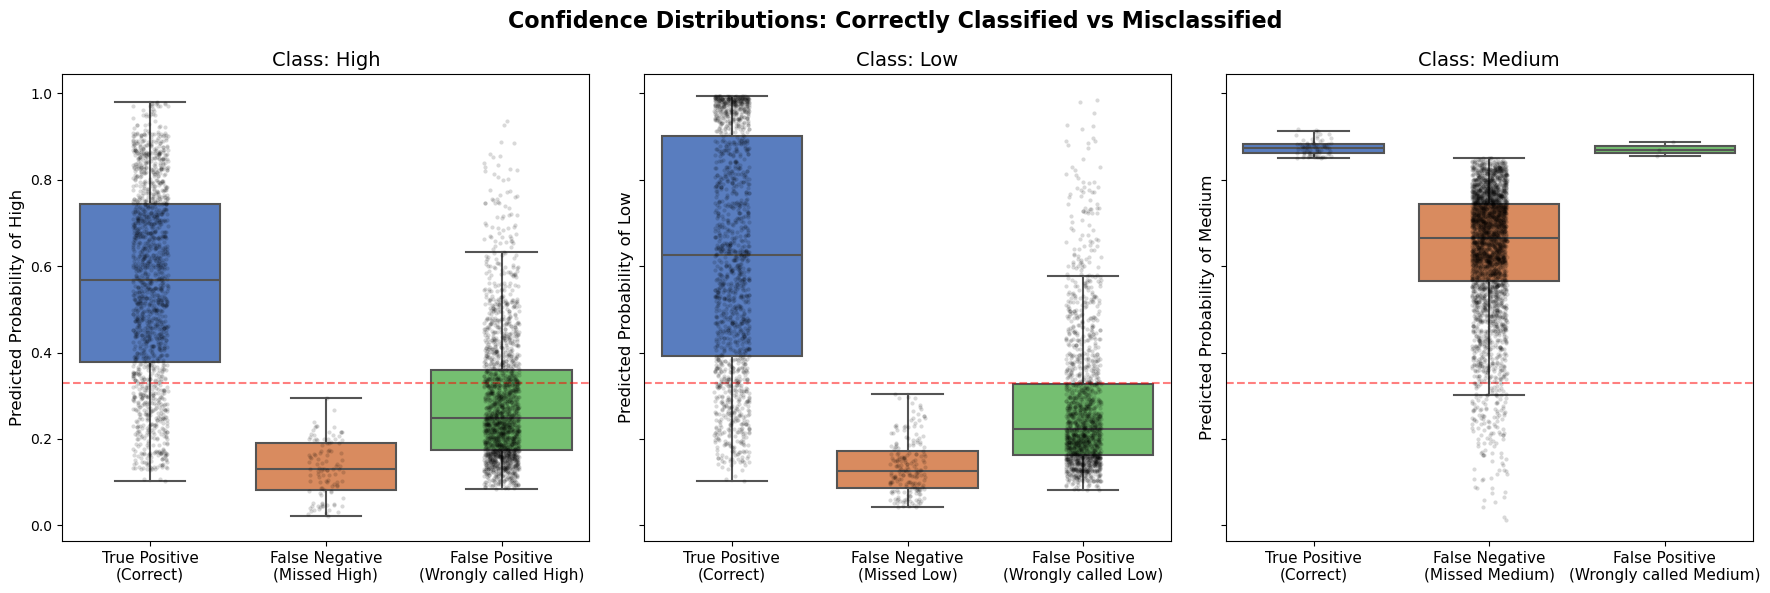

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── 1. Prepare the Data for Visualization ──────────────────────────────────────
# Make sure to run this after your model predictions (using y_prob_te and yp_te)
# If you used the threshold sweep code earlier, you can use the resulting `yp_te`
df_viz = pd.DataFrame(y_prob_te, columns=le.classes_)
df_viz['True_Class'] = le.inverse_transform(y_te_enc)
df_viz['Predicted_Class'] = le.inverse_transform(yp_te)

# ── 2. Create the Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Confidence Distributions: Correctly Classified vs Misclassified', 
             fontsize=16, fontweight='bold')

for i, cls in enumerate(le.classes_):
    # Categorize the predictions for the current class
    conditions = [
        (df_viz['True_Class'] == cls) & (df_viz['Predicted_Class'] == cls),  # True Positive
        (df_viz['True_Class'] == cls) & (df_viz['Predicted_Class'] != cls),  # False Negative
        (df_viz['True_Class'] != cls) & (df_viz['Predicted_Class'] == cls)   # False Positive
    ]
    choices = [
        'True Positive\n(Correct)',
        f'False Negative\n(Missed {cls})',
        f'False Positive\n(Wrongly called {cls})'
    ]
    
    # Apply conditions (using numpy select for speed)
    df_viz['Category'] = np.select(conditions, choices, default='Ignore')
    
    # Filter out the instances that don't involve the current class at all
    plot_data = df_viz[df_viz['Category'] != 'Ignore']
    
    # Draw the Boxplot
    sns.boxplot(
        data=plot_data, x='Category', y=cls, ax=axes[i], 
        palette='muted', order=choices, showfliers=False
    )
    # Overlay a Stripplot to show the actual point density
    sns.stripplot(
        data=plot_data, x='Category', y=cls, ax=axes[i], 
        color='black', alpha=0.15, size=3, order=choices, jitter=True
    )
    
    # Formatting
    axes[i].set_title(f'Class: {cls}', fontsize=14)
    axes[i].set_ylabel(f'Predicted Probability of {cls}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=11)
    
    # Add a horizontal line at the random guess threshold (0.33)
    axes[i].axhline(0.33, color='red', linestyle='--', alpha=0.5, label='Random Guess (0.33)')

plt.tight_layout()
plt.show()

StatementMeta(, fae1eef7-70e3-4a86-8f23-e03ce349af7f, 22, Finished, Available, Finished, False)

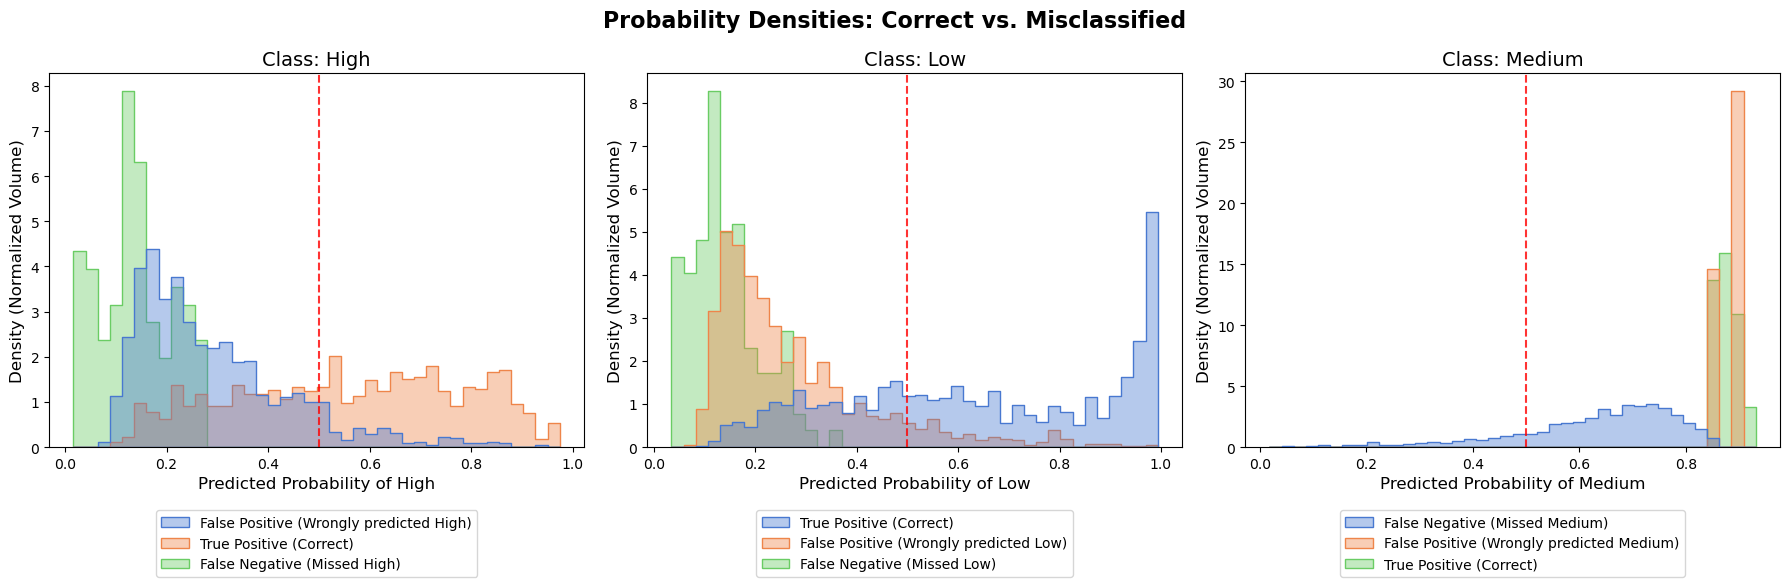

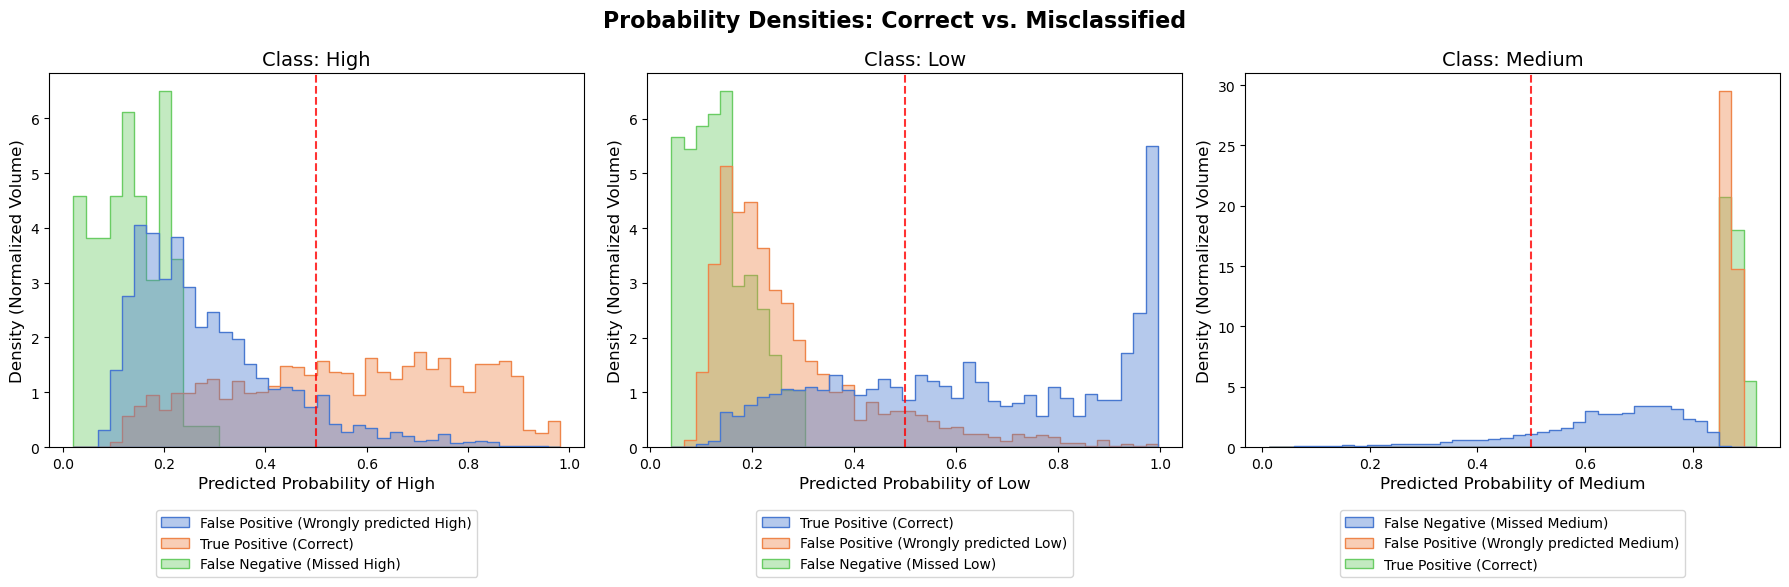

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── 1. Prepare the Data ────────────────────────────────────────────────────────
# (Assuming y_prob_te and yp_te are still in memory from the previous script)
df_viz = pd.DataFrame(y_prob_te, columns=le.classes_)
df_viz['True_Class'] = le.inverse_transform(y_te_enc)
df_viz['Predicted_Class'] = le.inverse_transform(yp_te)

# ── 2. Create the Overlaid Histograms ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) 
fig.suptitle('Probability Densities: Correct vs. Misclassified', fontsize=16, fontweight='bold')

for i, cls in enumerate(le.classes_):
    # Categorize predictions for the current class
    conditions = [
        (df_viz['True_Class'] == cls) & (df_viz['Predicted_Class'] == cls),  # True Positive
        (df_viz['True_Class'] == cls) & (df_viz['Predicted_Class'] != cls),  # False Negative
        (df_viz['True_Class'] != cls) & (df_viz['Predicted_Class'] == cls)   # False Positive
    ]
    choices = [
        'True Positive (Correct)',
        f'False Negative (Missed {cls})',
        f'False Positive (Wrongly predicted {cls})'
    ]
    
    df_viz['Category'] = np.select(conditions, choices, default='Ignore')
    plot_data = df_viz[df_viz['Category'] != 'Ignore']
    
    # Draw the histogram
    sns.histplot(
        data=plot_data, 
        x=cls, 
        hue='Category', 
        ax=axes[i], 
        element='step',      # 'step' is much cleaner for overlays than standard bars
        fill=True,
        stat='density',      # Normalizes the y-axis so we can compare shapes directly
        common_norm=False,   # Calculates density independently for each group
        palette='muted',
        alpha=0.4,
        bins=40              # Adjust bins if the data looks too chunky or too noisy
    )
    
    # Formatting
    axes[i].set_title(f'Class: {cls}', fontsize=14)
    axes[i].set_xlabel(f'Predicted Probability of {cls}', fontsize=12)
    axes[i].set_ylabel('Density (Normalized Volume)', fontsize=12)
    
    # Add a vertical line for the base random guess threshold (50%)
    axes[i].axvline(0.50, color='red', linestyle='--', alpha=0.8, label='Random Guess (0.33)')
    
    # Tidy up the legend so it doesn't block the data
    sns.move_legend(axes[i], "upper center", title=None, fontsize=10, bbox_to_anchor=(0.5, -0.15), ncol=1)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25) # Make room for the legends below the plots
plt.show()

StatementMeta(, cd1f6930-e3ba-4fe0-bf92-07c6fde7d684, 43, Finished, Available, Finished, False)

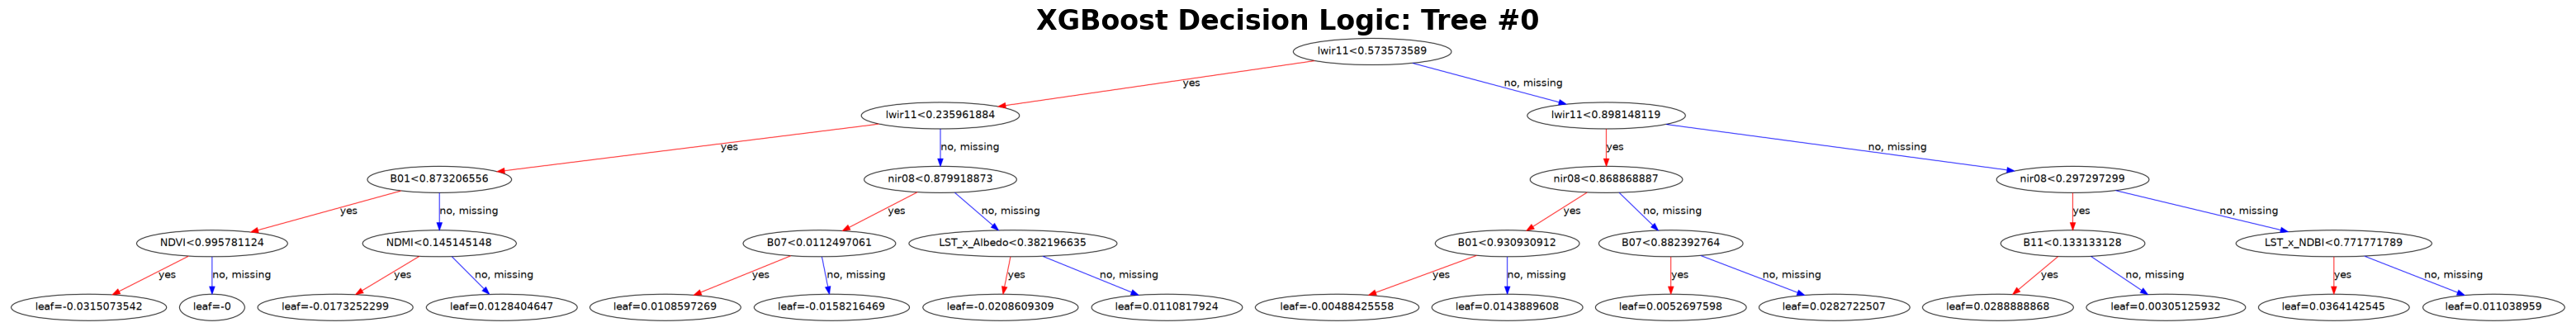

In [32]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Set up a massive figure size because trees get wide quickly
fig, ax = plt.subplots(figsize=(40, 15))

# Plot the very first tree built for the first class
# Change num_trees to 1 or 2 to see the trees for the other classes in the first round
xgb.plot_tree(m3, num_trees=0, ax=ax, rankdir='TB')

m3.get_booster().feature_names = list(X_train.columns)

plt.title("XGBoost Decision Logic: Tree #0", fontsize=24, fontweight='bold')
plt.show()

# Optional: If you want to export it as a high-res image to zoom in:
# plt.savefig("xgboost_tree_0.png", dpi=300, bbox_inches='tight')

StatementMeta(, cd1f6930-e3ba-4fe0-bf92-07c6fde7d684, 42, Finished, Available, Finished, False)

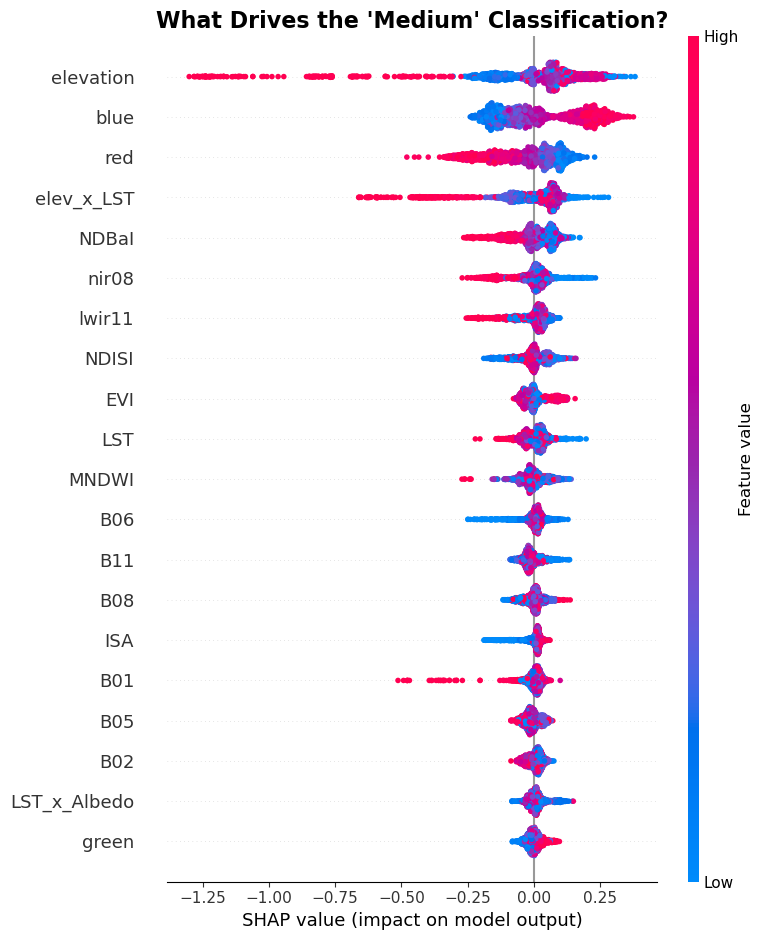

In [31]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer with your trained XGBoost model
explainer = shap.TreeExplainer(m3)

# 2. Calculate SHAP values for a sample of the test set (using 2000 to keep it fast)
# We pass the quantile-transformed data because that's what the model expects
X_te_sample = X_te_q[:2000]
shap_values = explainer.shap_values(X_te_sample)

# 3. Identify the index for the Medium class (usually 2, but we use your med_idx)
med_idx = list(le.classes_).index("Medium")

# 4. Plot the summary for the Medium class
# We pass X_train.columns so the y-axis shows actual feature names (elevation, LST, etc.)
plt.figure(figsize=(12, 8))
plt.title("What Drives the 'Medium' Classification?", fontsize=16, fontweight='bold')

shap.summary_plot(
    shap_values[med_idx], 
    X_te_sample, 
    feature_names=X_train.columns, 
    show=False
)
plt.tight_layout()
plt.show()

StatementMeta(, cd1f6930-e3ba-4fe0-bf92-07c6fde7d684, 36, Finished, Available, Finished, False)

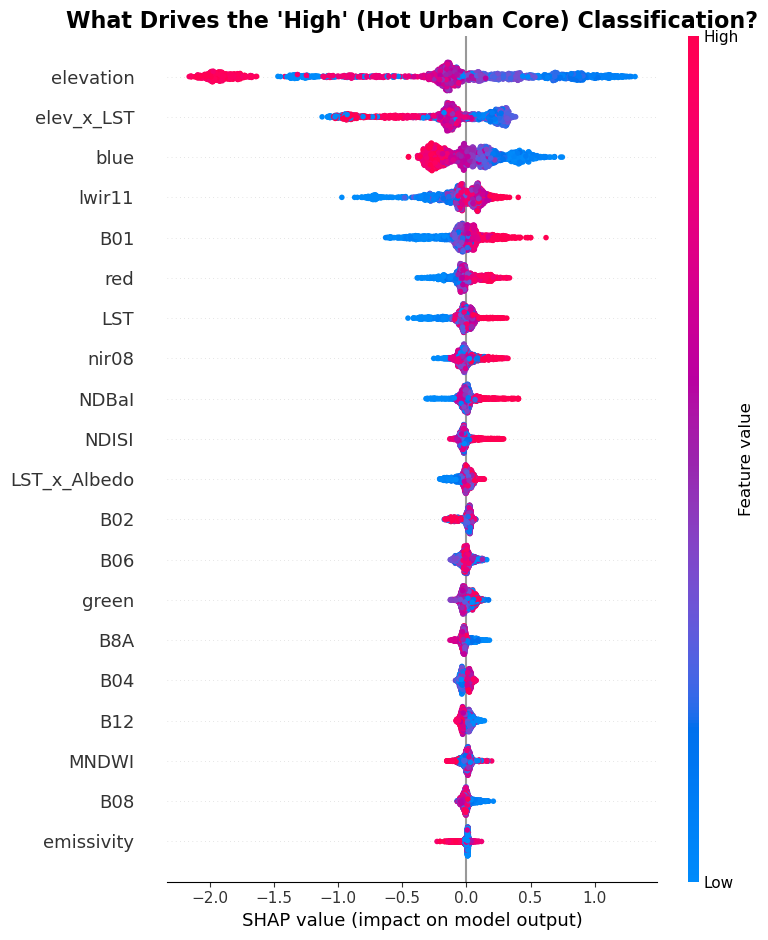

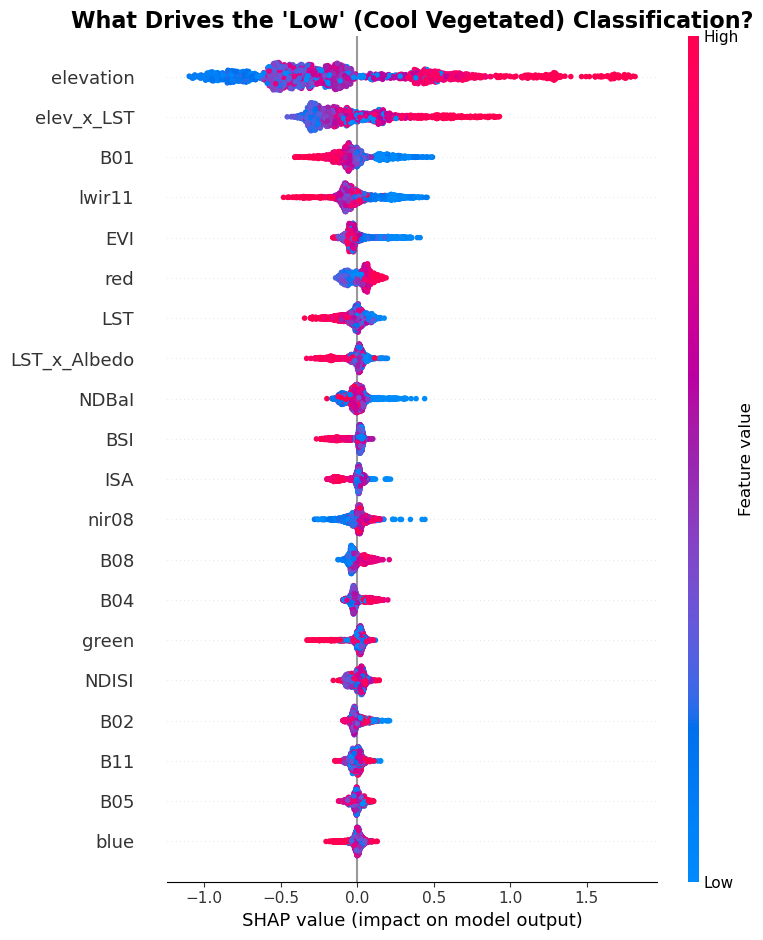

In [25]:
# 1. Dynamically find the indices for High and Low from your LabelEncoder
high_idx = list(le.classes_).index("High")
low_idx = list(le.classes_).index("Low")

# 2. Plot the SHAP summary for the 'High' class
plt.figure(figsize=(12, 8))
plt.title("What Drives the 'High' (Hot Urban Core) Classification?", fontsize=16, fontweight='bold')
shap.summary_plot(
    shap_values[high_idx], 
    X_te_sample, 
    feature_names=X_train.columns, 
    show=False
)
plt.tight_layout()
plt.show()

# 3. Plot the SHAP summary for the 'Low' class
plt.figure(figsize=(12, 8))
plt.title("What Drives the 'Low' (Cool Vegetated) Classification?", fontsize=16, fontweight='bold')
shap.summary_plot(
    shap_values[low_idx], 
    X_te_sample, 
    feature_names=X_train.columns, 
    show=False
)
plt.tight_layout()
plt.show()

StatementMeta(, cd1f6930-e3ba-4fe0-bf92-07c6fde7d684, 40, Finished, Available, Finished, False)

Total pixels above 600m: 466
------------------------------
UHI_Class
Low       464
Medium      2
High        0
Name: count, dtype: int64


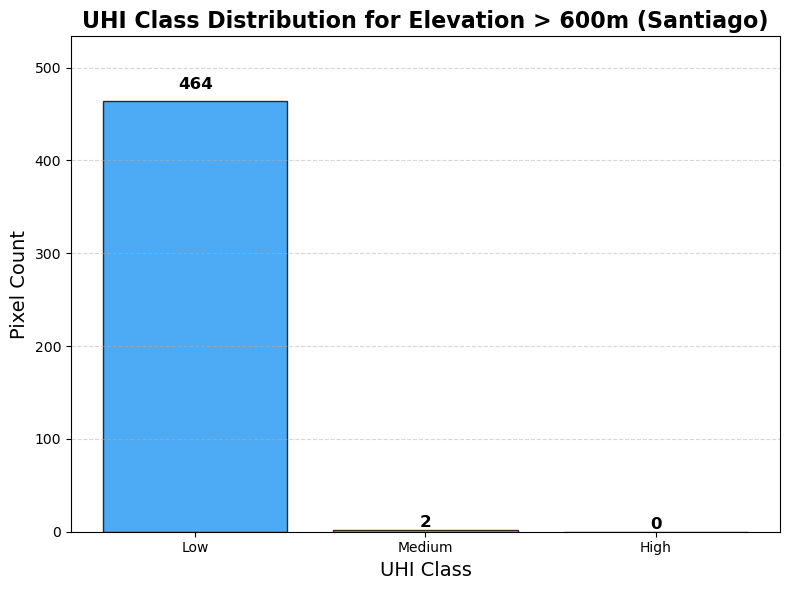

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the training data for elevation > 600m
high_elev_df = train_100[train_100['elevation'] > 900]

# 2. Count the occurrences of each UHI Class
uhi_counts = high_elev_df['UHI_Class'].value_counts().reindex(['Low', 'Medium', 'High'], fill_value=0)

# Print the exact numbers
print(f"Total pixels above 600m: {len(high_elev_df)}")
print("-" * 30)
print(uhi_counts)

# 3. Create the Plot
plt.figure(figsize=(8, 6))
colors = {'Low': '#2196F3', 'Medium': '#FF9800', 'High': '#F44336'}

# Plot the bars
bars = plt.bar(uhi_counts.index, uhi_counts.values, color=[colors[c] for c in uhi_counts.index], edgecolor='black', alpha=0.8)

# Add the exact count numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
             f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
plt.title('UHI Class Distribution for Elevation > 600m (Santiago)', fontsize=16, fontweight='bold')
plt.xlabel('UHI Class', fontsize=14)
plt.ylabel('Pixel Count', fontsize=14)
plt.ylim(0, max(uhi_counts.values) * 1.15) # Add headroom for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

StatementMeta(, cbcc02c6-4b00-461c-8011-1140a12f574d, 5, Finished, Available, Finished, False)

--- 0. Loading Data from Lakehouse ---

--- 1. Preparing Data ---
Dropped features: ['elevation', 'elev_x_LST']. Remaining features: 43

--- 2. Training XGBoost Model ---


Training complete.

--- 3. Optimizing 'Medium' Probability Threshold ---
Optimal Threshold for Medium: 0.710
Test F1 at this threshold:    0.4765
Total Penalty Cost:           3494

--- 4. Generating Density Visualizations ---


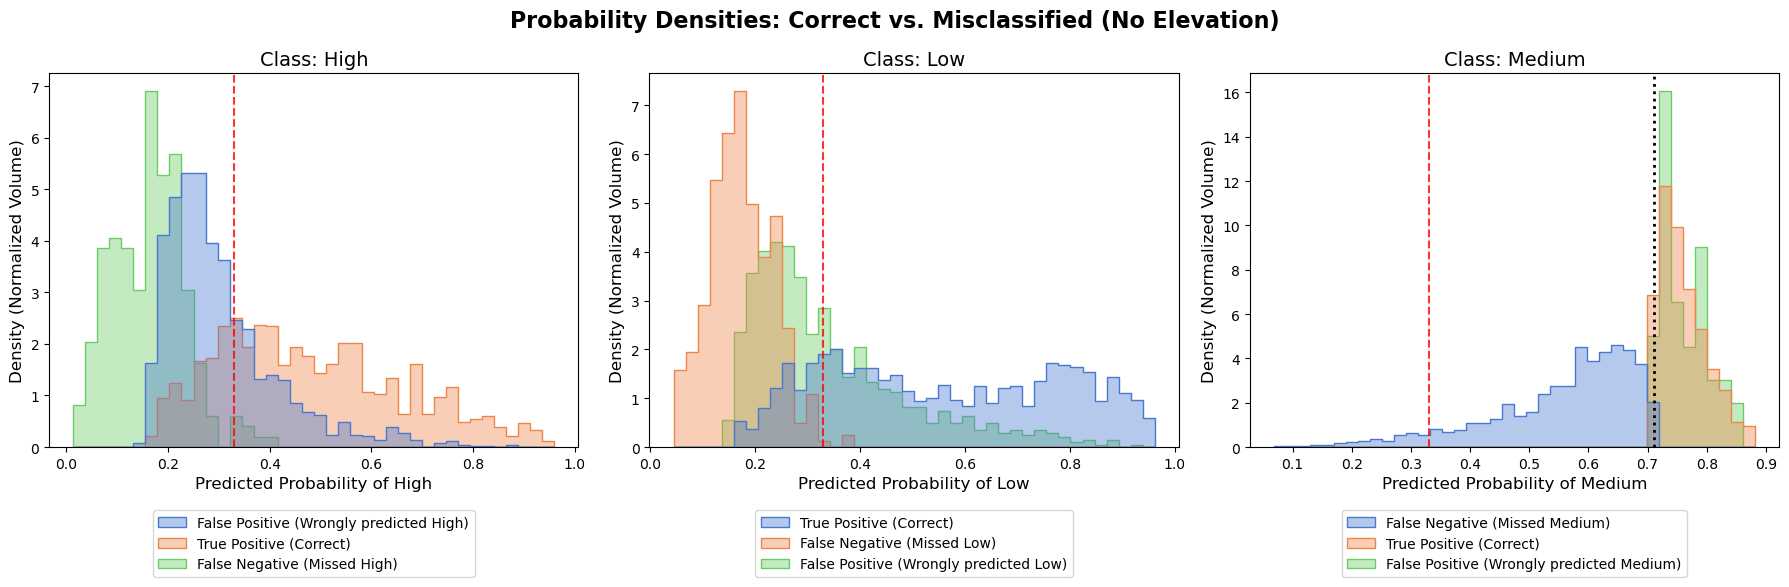


--- 5. Generating SHAP Feature Importance Visualizations ---


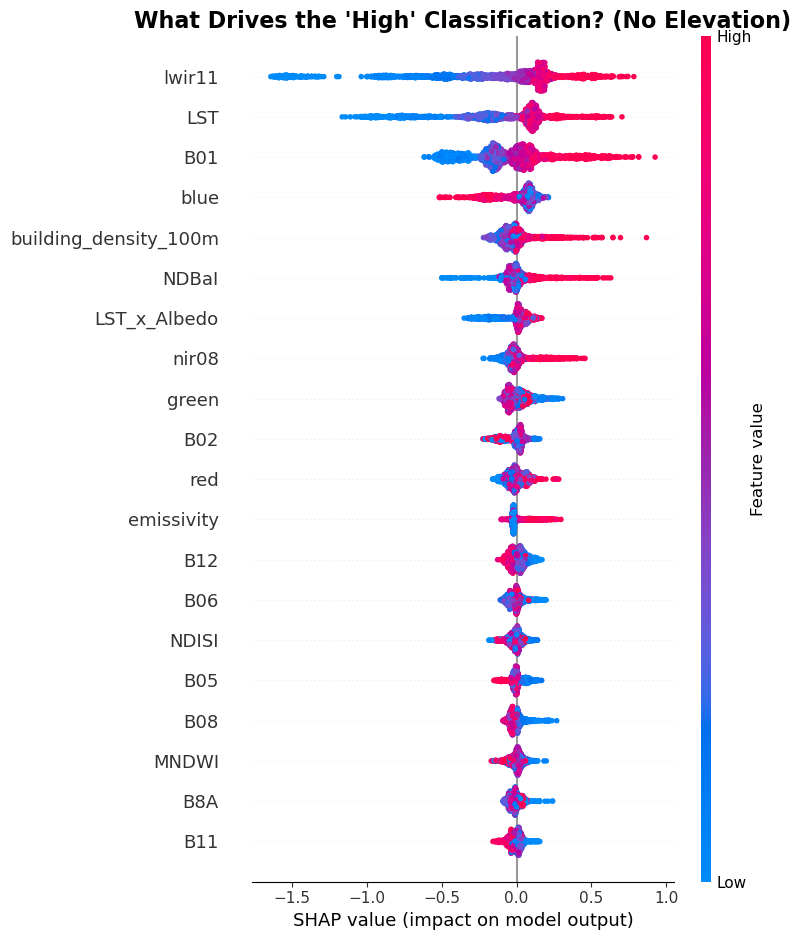

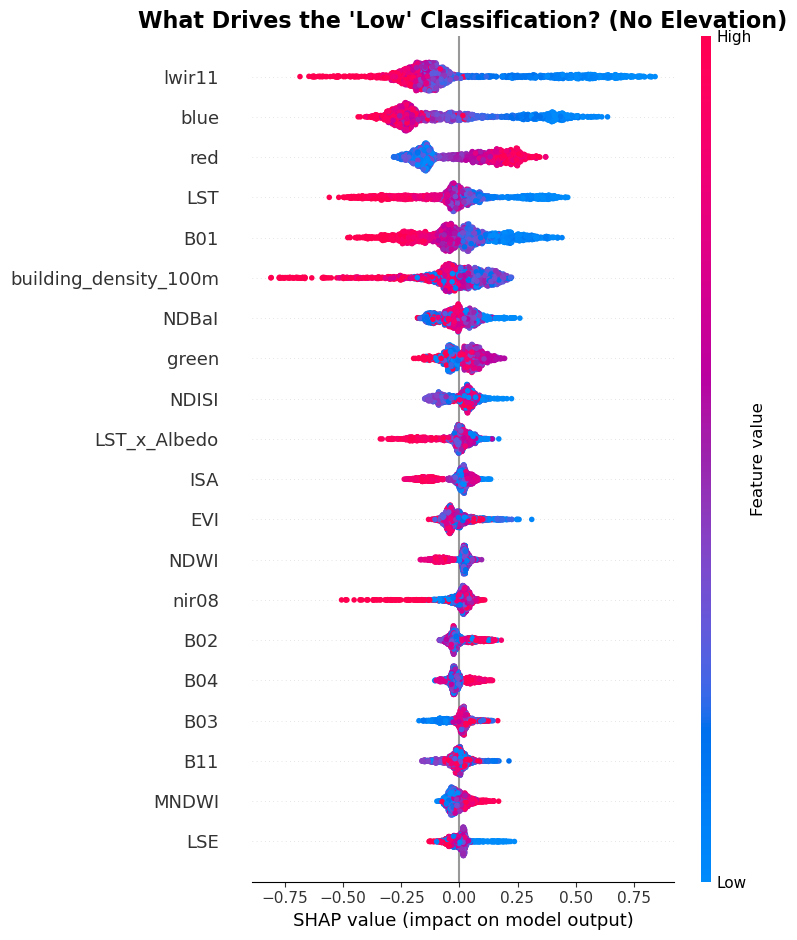

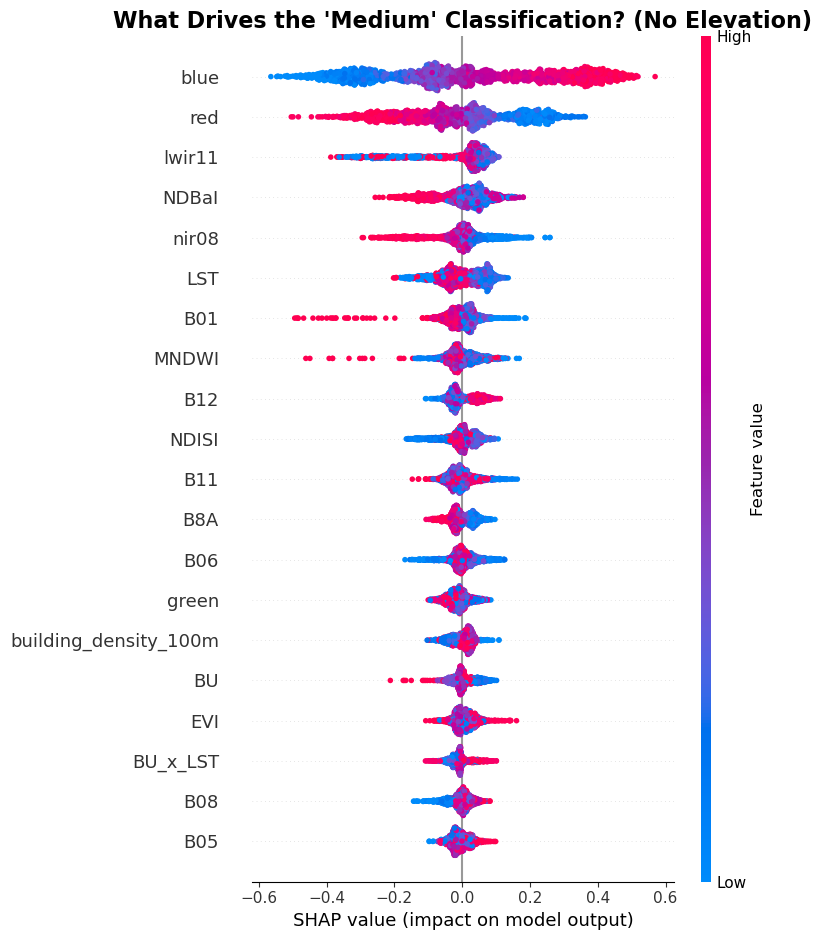

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# 0. HELPER FUNCTIONS & DATA LOADING
# =============================================================================
print("--- 0. Loading Data from Lakehouse ---")

def engineer_features(df):
    df = df.copy()
    df["LST_x_NDVI"] = df["LST"] * df["NDVI"]
    df["LST_x_NDBI"] = df["LST"] * df["NDBI"]
    df["elev_x_LST"] = df["elevation"] * df["LST"]
    df["NDVI_minus_NDBI"] = df["NDVI"] - df["NDBI"]
    df["LST_x_Albedo"] = df["LST"] * df["Albedo"]
    df["BU_x_LST"] = df["BU"] * df["LST"]
    if "NDVI_Landsat" in df.columns:
        df.drop(columns=["NDVI_Landsat"], inplace=True)
    return df

def prepare_xy(df):
    df = engineer_features(df)
    drop_cols = [c for c in ["Latitude","Longitude","UHI_Class","label","resolution_m"] if c in df.columns]
    y = df["UHI_Class"] if "UHI_Class" in df.columns else None
    X = df.drop(columns=drop_cols)
    X = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

# Load the data exactly as it was done in your notebook
DATA_DIR = "/lakehouse/default/Files/uhi_pipe_output/datasets"
df_100 = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")
train_100 = df_100[df_100["label"] == "Chile"].dropna(subset=["UHI_Class"]).copy()


# =============================================================================
# 1. DATA PREPARATION (Dropping Elevation)
# =============================================================================
print("\n--- 1. Preparing Data ---")
X_train_full, y_train = prepare_xy(train_100)

# Explicitly drop elevation and its interaction term
cols_to_drop = ['elevation', 'elev_x_LST']
X_train = X_train_full.drop(columns=[c for c in cols_to_drop if c in X_train_full.columns])
print(f"Dropped features: {cols_to_drop}. Remaining features: {X_train.shape[1]}")

# Train/Test Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=42
)

# Encode Labels
le = LabelEncoder()
y_tr_enc = le.fit_transform(y_tr)
y_te_enc = le.transform(y_te)

# Quantile Transformation
qt = QuantileTransformer(n_quantiles=min(1000, len(X_tr)), output_distribution="uniform", random_state=42)
X_tr_q = qt.fit_transform(X_tr.values)
X_te_q = qt.transform(X_te.values)


# =============================================================================
# 2. MODEL TRAINING
# =============================================================================
print("\n--- 2. Training XGBoost Model ---")
m3 = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
    eval_metric="mlogloss", random_state=42
)
m3.fit(X_tr_q, y_tr_enc)

# Re-map feature names so the SHAP plots show actual names instead of "f0, f1"
m3.get_booster().feature_names = list(X_train.columns)
print("Training complete.")


# =============================================================================
# 3. COST-BASED THRESHOLD SWEEP (Penalizing 'Medium')
# =============================================================================
print("\n--- 3. Optimizing 'Medium' Probability Threshold ---")
COST_FALSE_MEDIUM = 5  
COST_OTHER_ERROR = 1   

y_prob_te = m3.predict_proba(X_te_q)
med_idx = list(le.classes_).index("Medium")
other_idx = [i for i in range(len(le.classes_)) if i != med_idx]

thresholds = np.linspace(0.33, 0.85, 250)
costs, f1_tests = [], []

for t in thresholds:
    yp_te = np.argmax(y_prob_te, axis=1)
    med_mask_te = (yp_te == med_idx) & (y_prob_te[:, med_idx] < t)
    
    # Fallback logic
    if np.any(med_mask_te):
        yp_te[med_mask_te] = np.array(other_idx)[np.argmax(y_prob_te[med_mask_te][:, other_idx], axis=1)]

    # Metrics
    f1_te = f1_score(y_te_enc, yp_te, average="weighted", zero_division=0)
    cm = confusion_matrix(y_te_enc, yp_te)
    
    false_mediums = sum(cm[i, med_idx] for i in other_idx)
    other_errors = (np.sum(cm) - np.trace(cm)) - false_mediums
    
    costs.append((false_mediums * COST_FALSE_MEDIUM) + (other_errors * COST_OTHER_ERROR))
    f1_tests.append(f1_te)

best_cost_idx = np.argmin(costs)
optimal_t = thresholds[best_cost_idx]

print(f"Optimal Threshold for Medium: {optimal_t:.3f}")
print(f"Test F1 at this threshold:    {f1_tests[best_cost_idx]:.4f}")
print(f"Total Penalty Cost:           {costs[best_cost_idx]}")


# Apply the optimal threshold to get our final predictions for the visualization
yp_te_best = np.argmax(y_prob_te, axis=1)
med_mask_best = (yp_te_best == med_idx) & (y_prob_te[:, med_idx] < optimal_t)
if np.any(med_mask_best):
    yp_te_best[med_mask_best] = np.array(other_idx)[np.argmax(y_prob_te[med_mask_best][:, other_idx], axis=1)]


# =============================================================================
# 4. VISUALIZATION: PROBABILITY DENSITIES
# =============================================================================
print("\n--- 4. Generating Density Visualizations ---")

df_viz = pd.DataFrame(y_prob_te, columns=le.classes_)
df_viz['True_Class'] = le.inverse_transform(y_te_enc)
df_viz['Predicted_Class'] = le.inverse_transform(yp_te_best)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) 
fig.suptitle('Probability Densities: Correct vs. Misclassified (No Elevation)', fontsize=16, fontweight='bold')

for i, cls in enumerate(le.classes_):
    conditions = [
        (df_viz['True_Class'] == cls) & (df_viz['Predicted_Class'] == cls),
        (df_viz['True_Class'] == cls) & (df_viz['Predicted_Class'] != cls),
        (df_viz['True_Class'] != cls) & (df_viz['Predicted_Class'] == cls) 
    ]
    choices = [
        'True Positive (Correct)',
        f'False Negative (Missed {cls})',
        f'False Positive (Wrongly predicted {cls})'
    ]
    
    df_viz['Category'] = np.select(conditions, choices, default='Ignore')
    plot_data = df_viz[df_viz['Category'] != 'Ignore']
    
    sns.histplot(
        data=plot_data, x=cls, hue='Category', ax=axes[i], 
        element='step', fill=True, stat='density', common_norm=False, 
        palette='muted', alpha=0.4, bins=40
    )
    
    axes[i].set_title(f'Class: {cls}', fontsize=14)
    axes[i].set_xlabel(f'Predicted Probability of {cls}', fontsize=12)
    axes[i].set_ylabel('Density (Normalized Volume)', fontsize=12)
    axes[i].axvline(0.33, color='red', linestyle='--', alpha=0.8, label='Random Guess (0.33)')
    if cls == "Medium":
        axes[i].axvline(optimal_t, color='black', linestyle=':', linewidth=2, label=f'Strict Threshold ({optimal_t:.2f})')
    
    sns.move_legend(axes[i], "upper center", title=None, fontsize=10, bbox_to_anchor=(0.5, -0.15), ncol=1)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()


# =============================================================================
# 5. VISUALIZATION: SHAP FEATURE IMPORTANCE
# =============================================================================
print("\n--- 5. Generating SHAP Feature Importance Visualizations ---")
explainer = shap.TreeExplainer(m3)
X_te_sample = X_te_q[:2000] # Sample to keep plotting fast
shap_values = explainer.shap_values(X_te_sample)

# Loop through all classes and plot SHAP summaries
for cls in ["High", "Low", "Medium"]:
    idx = list(le.classes_).index(cls)
    plt.figure(figsize=(10, 6))
    plt.title(f"What Drives the '{cls}' Classification? (No Elevation)", fontsize=16, fontweight='bold')
    shap.summary_plot(
        shap_values[idx], 
        X_te_sample, 
        feature_names=X_train.columns, 
        show=False
    )

In [4]:
# =============================================================================
# 3. COST-BASED THRESHOLD SWEEP & GAP ANALYSIS
# =============================================================================
print("\n--- 3. Optimizing 'Medium' Threshold & Calculating F1 Gap ---")
COST_FALSE_MEDIUM = 5  
COST_OTHER_ERROR = 1   

# Get probabilities for BOTH test and train to calculate the gap
y_prob_te = m3.predict_proba(X_te_q)
y_prob_tr = m3.predict_proba(X_tr_q) 

med_idx = list(le.classes_).index("Medium")
other_idx = [i for i in range(len(le.classes_)) if i != med_idx]

thresholds = np.linspace(0.33, 0.85, 250)
costs, f1_tests, f1_trains, f1_gaps = [], [], [], []

for t in thresholds:
    # --- Test Predictions ---
    yp_te = np.argmax(y_prob_te, axis=1)
    med_mask_te = (yp_te == med_idx) & (y_prob_te[:, med_idx] < t)
    if np.any(med_mask_te):
        yp_te[med_mask_te] = np.array(other_idx)[np.argmax(y_prob_te[med_mask_te][:, other_idx], axis=1)]

    # --- Train Predictions ---
    yp_tr = np.argmax(y_prob_tr, axis=1)
    med_mask_tr = (yp_tr == med_idx) & (y_prob_tr[:, med_idx] < t)
    if np.any(med_mask_tr):
        yp_tr[med_mask_tr] = np.array(other_idx)[np.argmax(y_prob_tr[med_mask_tr][:, other_idx], axis=1)]

    # --- Calculate Metrics ---
    f1_te = f1_score(y_te_enc, yp_te, average="weighted", zero_division=0)
    f1_tr = f1_score(y_tr_enc, yp_tr, average="weighted", zero_division=0)
    
    cm = confusion_matrix(y_te_enc, yp_te)
    false_mediums = sum(cm[i, med_idx] for i in other_idx)
    other_errors = (np.sum(cm) - np.trace(cm)) - false_mediums
    
    costs.append((false_mediums * COST_FALSE_MEDIUM) + (other_errors * COST_OTHER_ERROR))
    f1_tests.append(f1_te)
    f1_trains.append(f1_tr)
    f1_gaps.append(f1_tr - f1_te)

# Find the threshold that minimized the custom penalty cost
best_cost_idx = np.argmin(costs)
optimal_t = thresholds[best_cost_idx]

# --- Print the Diagnosis ---
print("="*60)
print(f"  Best Cost-Reduction Threshold: {optimal_t:.3f}")
print("="*60)
print(f"  Test F1:      {f1_tests[best_cost_idx]:.4f}")
print(f"  Train F1:     {f1_trains[best_cost_idx]:.4f}")
print(f"  F1 Gap:       {f1_gaps[best_cost_idx]:.4f}  {'⚠ HIGH OVERFIT' if abs(f1_gaps[best_cost_idx]) > 0.05 else '✓ stable'}")
print(f"  Total Cost:   {costs[best_cost_idx]}")

# Apply the optimal threshold to get our final predictions for the visualization
yp_te_best = np.argmax(y_prob_te, axis=1)
med_mask_best = (yp_te_best == med_idx) & (y_prob_te[:, med_idx] < optimal_t)
if np.any(med_mask_best):
    yp_te_best[med_mask_best] = np.array(other_idx)[np.argmax(y_prob_te[med_mask_best][:, other_idx], axis=1)]

StatementMeta(, cbcc02c6-4b00-461c-8011-1140a12f574d, 6, Finished, Available, Finished, False)


--- 3. Optimizing 'Medium' Threshold & Calculating F1 Gap ---
  Best Cost-Reduction Threshold: 0.710
  Test F1:      0.4765
  Train F1:     0.5593
  F1 Gap:       0.0829  ⚠ HIGH OVERFIT
  Total Cost:   3494
